# 09 · Uncertainty-Aware Scoring

A single set of weights produces one score and one ranking — false precision. The v0.7 milestone perturbs the weights many times around a chosen profile (Dirichlet samples centred on it), rescores each time, and summarises the spread:

1. **Score confidence bands** — a 5th-95th percentile range per country.
2. **Rank stability** — how much each country's rank moves.
3. **Top-k probability** — the chance of landing in the highest-risk group.

Everything is deterministic given the seed, so the uncertainty is reproducible — and it is uncertainty about the *weighting choice*, not a forecast or a causal claim.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse, load_transition_mart
from carbon_transition_duckdb.risk.scoring import filter_entities
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )

mart = filter_entities(load_transition_mart(DB_PATH))
print(f"Mart: {mart.shape[0]} rows, {mart['country'].nunique()} countries")


Mart: 75 rows, 5 countries


## 1. Score confidence bands

`uncertainty_summary` returns, per country, the mean score, a 5th-95th percentile band, the rank range, and the probability of being in the top-k highest-risk countries.

In [3]:
from carbon_transition_duckdb.uncertainty import uncertainty_summary

summary = uncertainty_summary(mart, n_samples=500, seed=42, top_k=2)
summary

,country,score_mean,score_low,score_high,rank_median,rank_low,rank_high,prob_top_k,rank_uncertain
0,Deltora,68.85,65.14,72.51,1.0,1,1,1.0,False
1,Borealia,58.18,53.22,62.63,2.0,2,2,1.0,False
2,Atlantis,51.03,49.52,52.38,3.0,3,3,0.0,False
3,Estavia,15.41,13.95,16.84,4.0,4,4,0.0,False
4,Cyrenia,9.79,6.99,13.00,5.0,5,5,0.0,False


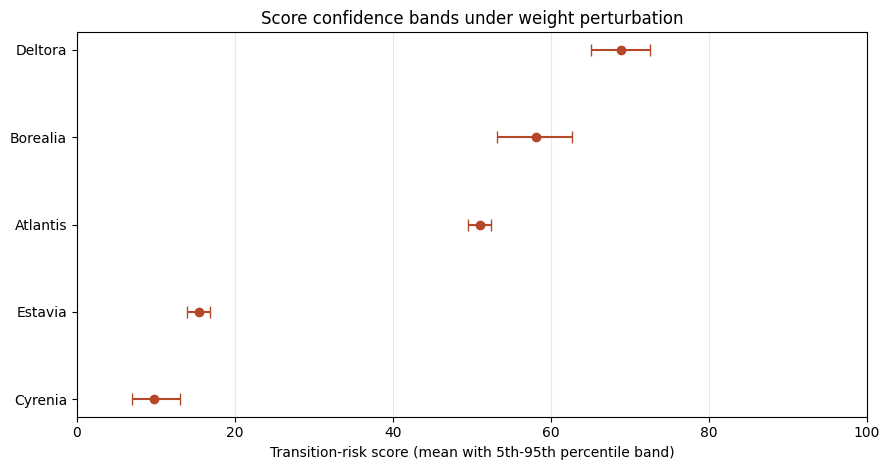

In [4]:
ordered = summary.sort_values('score_mean')
lower = (ordered['score_mean'] - ordered['score_low']).clip(lower=0)
upper = (ordered['score_high'] - ordered['score_mean']).clip(lower=0)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(ordered['score_mean'], ordered['country'],
            xerr=[lower, upper], fmt='o', color='#b5482a', capsize=4)
ax.set_xlabel('Transition-risk score (mean with 5th-95th percentile band)')
ax.set_title('Score confidence bands under weight perturbation')
ax.set_xlim(0, 100)
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
plt.show()

## 2. How the band widens with more weight jitter

A lower `concentration` lets the weights vary more, widening the bands. Comparing two settings shows how sensitive each country's score is to the weighting.

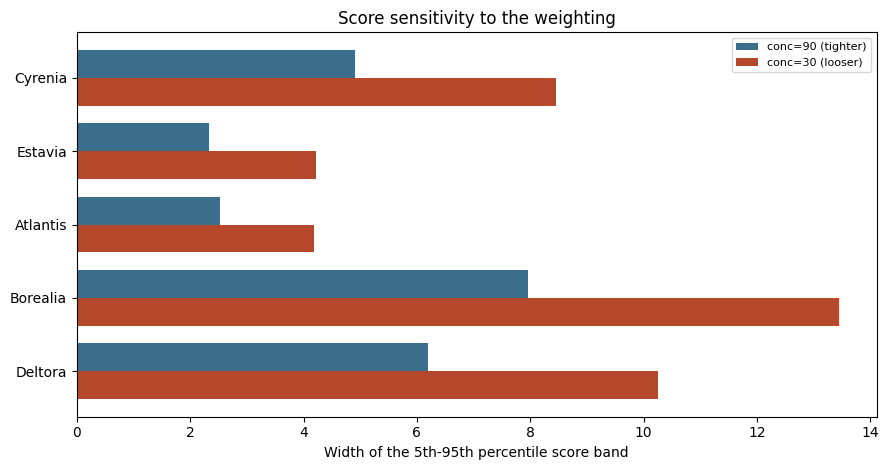

,conc=90,conc=30
country,,
Deltora,6.19,10.26
Borealia,7.96,13.44
Atlantis,2.52,4.18
Estavia,2.34,4.22
Cyrenia,4.91,8.46


In [5]:
order = summary.sort_values('score_mean', ascending=False)['country'].tolist()
widths = pd.DataFrame({'country': order})
for conc in (90, 30):
    s = uncertainty_summary(mart, n_samples=500, concentration=conc, seed=42)
    s = s.set_index('country')
    widths[f'conc={conc}'] = [
        round(s.loc[c, 'score_high'] - s.loc[c, 'score_low'], 2) for c in order
    ]
widths = widths.set_index('country')

fig, ax = plt.subplots(figsize=(9, 4.8))
y = range(len(order))
h = 0.38
ax.barh([v + h/2 for v in y], widths['conc=90'], height=h,
        label='conc=90 (tighter)', color='#3b6e8c')
ax.barh([v - h/2 for v in y], widths['conc=30'], height=h,
        label='conc=30 (looser)', color='#b5482a')
ax.set_yticks(list(y))
ax.set_yticklabels(order)
ax.set_xlabel('Width of the 5th-95th percentile score band')
ax.set_title('Score sensitivity to the weighting')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
widths

## 3. Top-k probability and rank stability

`prob_top_k` is the share of weight samples in which a country lands in the top-k highest-risk group. With well-separated countries the ranks are robust (`rank_uncertain` is False); on real OWID data, where peers are closer, this is where overlapping ranks surface.

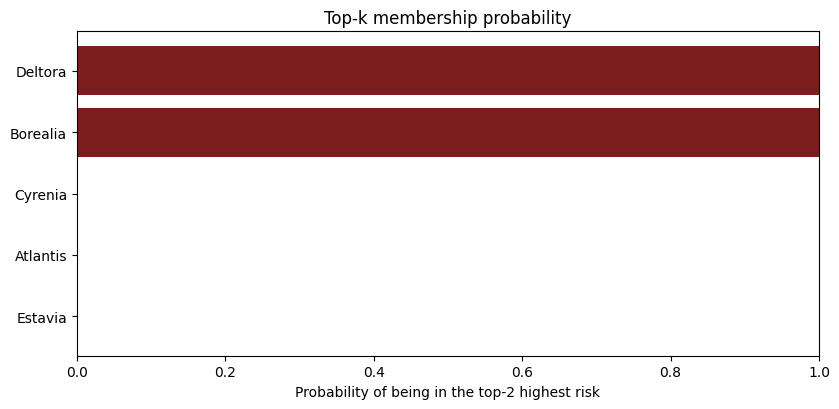

,country,rank_low,rank_high,prob_top_k,rank_uncertain
0,Deltora,1,1,1.0,False
1,Borealia,2,2,1.0,False
2,Atlantis,3,3,0.0,False
3,Estavia,4,4,0.0,False
4,Cyrenia,5,5,0.0,False


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ordered = summary.sort_values('prob_top_k')
ax.barh(ordered['country'], ordered['prob_top_k'], color='#7b1d1d')
ax.set_xlabel('Probability of being in the top-2 highest risk')
ax.set_xlim(0, 1)
ax.set_title('Top-k membership probability')
fig.tight_layout()
plt.show()
summary[['country', 'rank_low', 'rank_high', 'prob_top_k', 'rank_uncertain']]

## Takeaways

- Confidence bands replace a single score with an honest range, so close calls are visible instead of hidden.
- Band width measures how much a country's score depends on the weighting choice — a built-in sensitivity check.
- Rank stability and top-k probability say whether a ranking is robust or an artefact of one weighting.
- The synthetic countries are well-separated, so ranks here are stable; on real, closer peers the `rank_uncertain` flag earns its keep.